In [72]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
import matplotlib
from matplotlib import rc
from sklearn.metrics import r2_score
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
from datetime import date
import math

In [12]:
date_time = ["10-2020", "11-2020", "12-2020"]
date_time = pd.to_datetime(date_time, format = '%m-%Y')
data = [1, 2, 3]

In [18]:
df = pd.read_csv(r"D:\data_projects\Nat_Gas.csv")
df['Dates'] = pd.to_datetime(df['Dates'], format = '%m/%d/%y')
prices = df['Prices'].values
dates = df['Dates'].values

In [30]:
df

,Dates,Prices,time_in_days
0,2020-10-31,10.10,0.0
1,2020-11-30,10.30,31.0
2,2020-12-31,11.00,62.0
3,2021-01-31,10.90,94.0
4,2021-02-28,10.90,123.0
5,2021-03-31,10.90,154.0
6,2021-04-30,10.40,185.0
7,2021-05-31,9.84,217.0
8,2021-06-30,10.00,247.0
9,2021-07-31,10.10,279.0


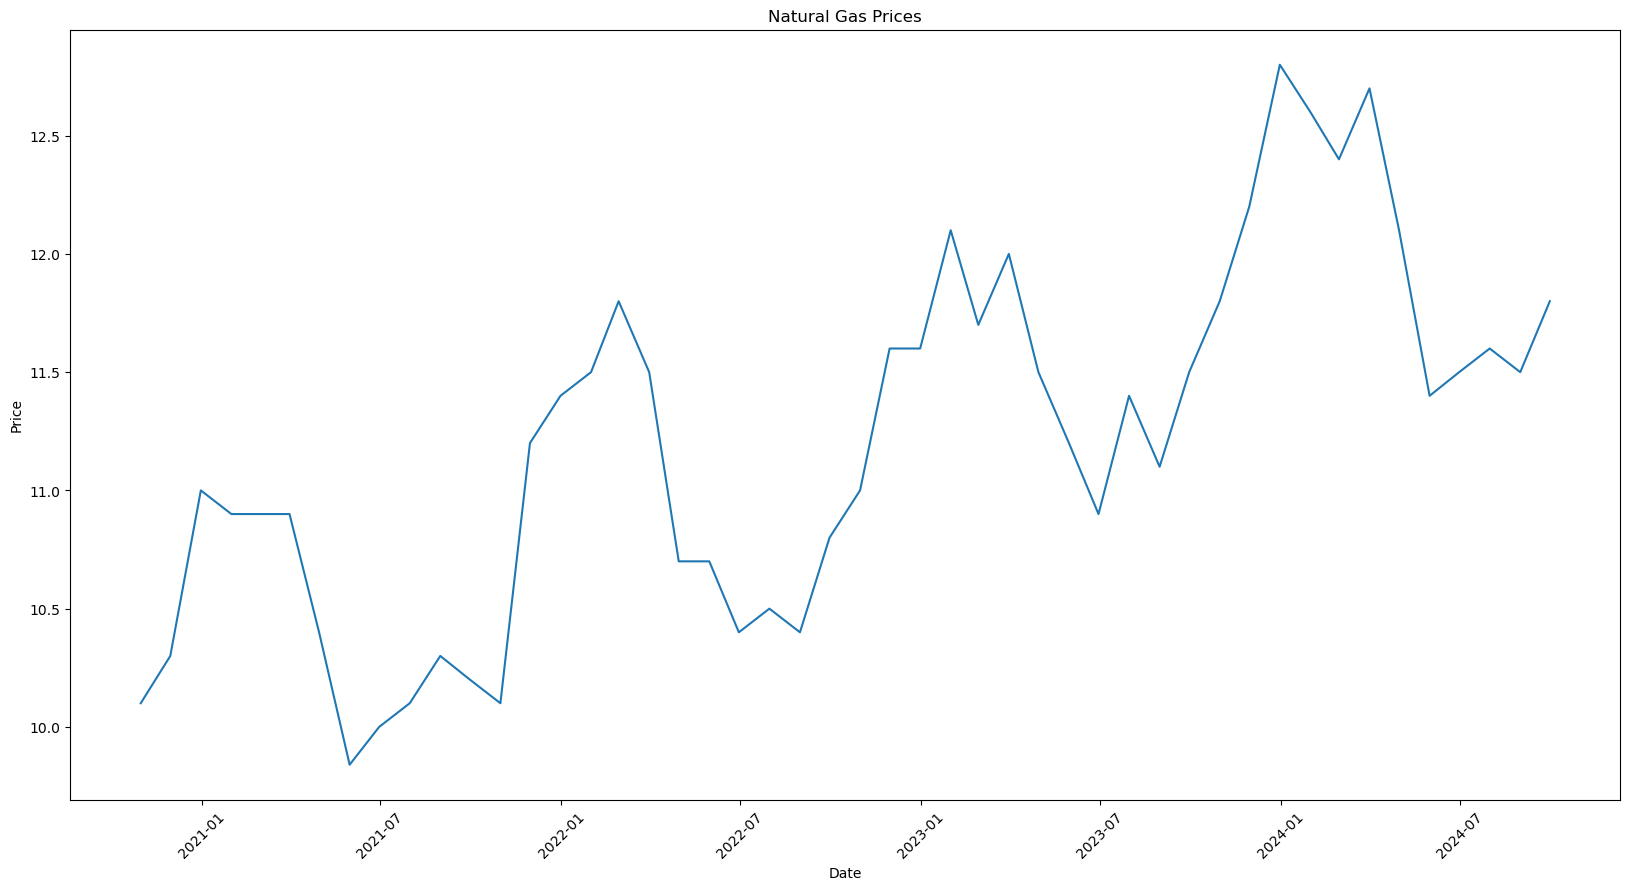

In [23]:
fig, ax = plt.subplots(figsize= (20, 10))
ax.plot(dates, prices)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title('Natural Gas Prices')
ax.tick_params(axis='x', rotation=45)
plt.show()

In [28]:
df['time_in_days'] = np.round((df['Dates'] - df['Dates'].min()).dt.total_seconds()/84600, 0) 

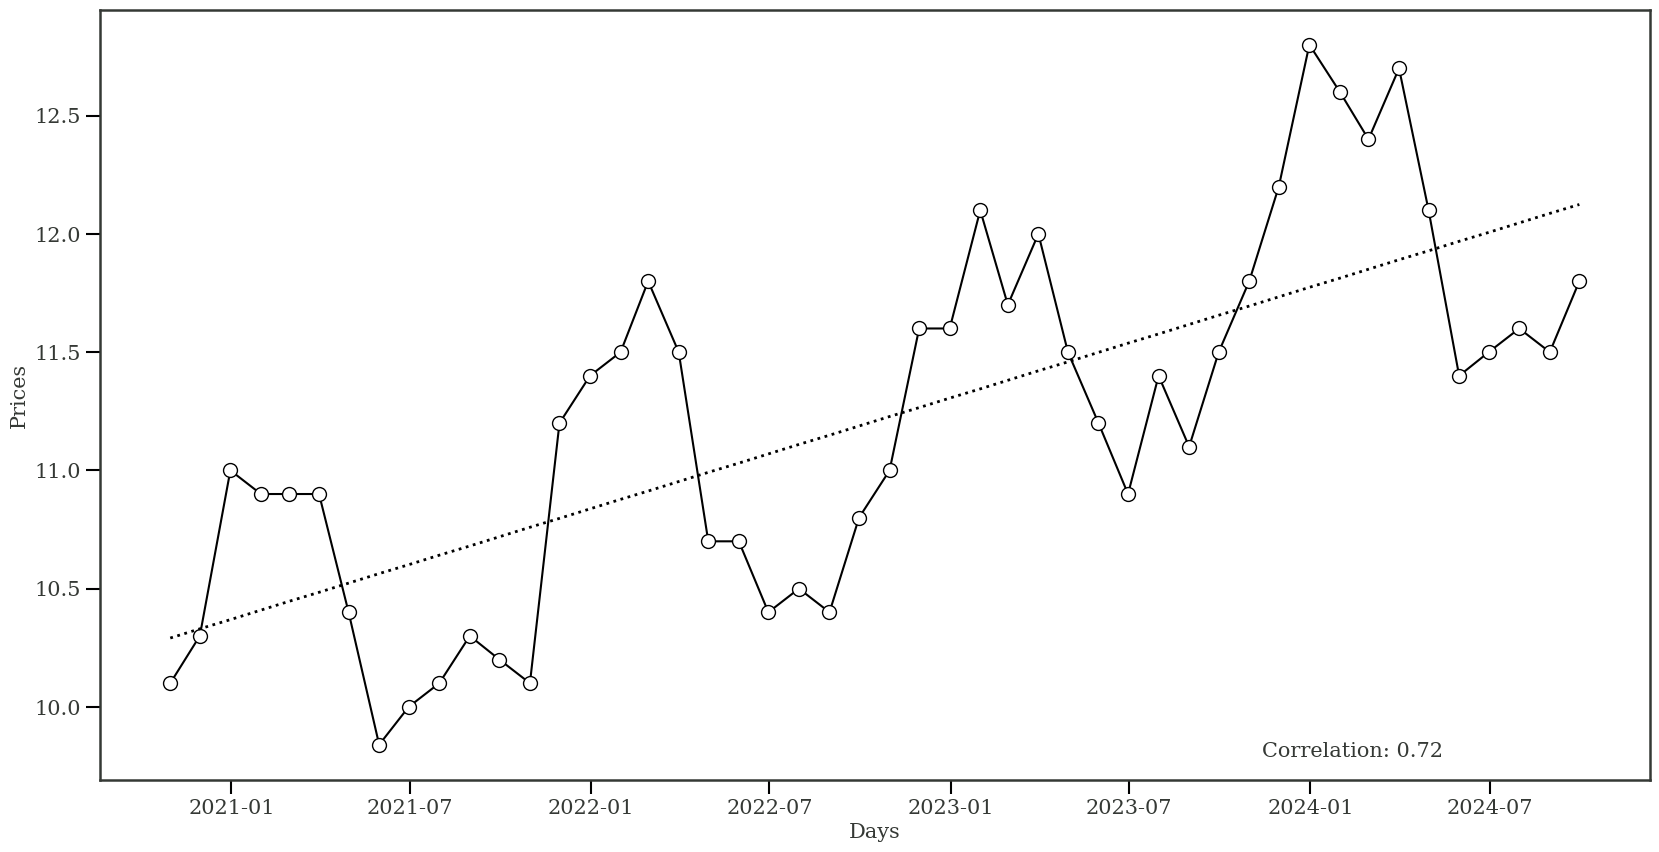

In [71]:
params = {
          'mathtext.rm'      : 'DejaVu serif',
          'font.family'      : 'DejaVu serif',
          'font.serif'       : "DejaVu serif",     
         }
matplotlib.rcParams.update(params)
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

(m, b) = np.polyfit(df['time_in_days'], df['Prices'], 1)
yp = np.polyval([m, b], df['time_in_days'])
correlation_coefficient = df['time_in_days'].corr(df['Prices'])

ax.plot(df['Dates'], df['Prices'], marker = 'o' ,markerfacecolor='white', markeredgecolor='black', markersize=10, linewidth=1.5, color = 'black')
ax.plot(df['Dates'], yp, linestyle=':', color='#000000', linewidth=2)

ax.text(0.75, 0.03, f'Correlation: {correlation_coefficient:.2f}', transform=ax.transAxes,
        fontsize=15, color='#353935', fontweight='normal', bbox=dict(facecolor='white', alpha=1, edgecolor='none'))

# ax.set_xlabel('$V \circ B_{{z}}$ \n (mV/m)', fontweight='normal', fontsize=15, color = '#353935')
ax.set_xlabel('Days', fontweight='normal', fontsize=15, color = '#353935')
ax.set_ylabel('Prices', fontweight='normal', fontsize=15, color = '#353935')
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')
ax.tick_params(axis='both', which='major', labelsize=15, width=1.5,  length=10)
ax.tick_params(axis = 'both', which='minor', width=1.5, length=3)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')   
plt.show()

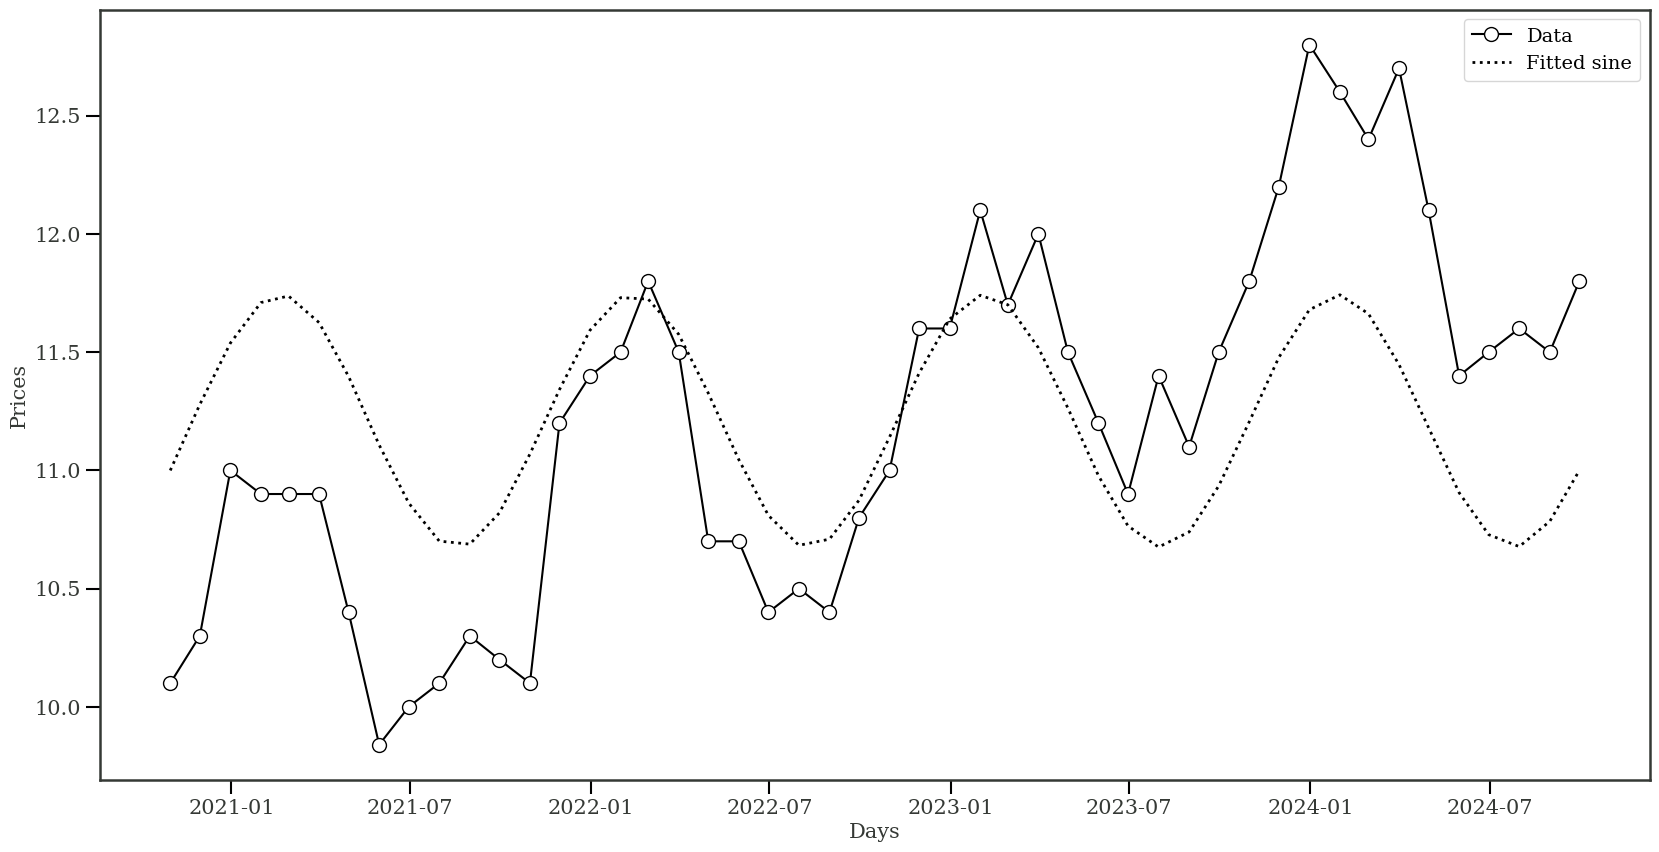

In [69]:
sin_time = np.sin(df['time_in_days'] * 2 * np.pi / 365)
cos_time = np.cos(df['time_in_days'] * 2 * np.pi / 365)
X = np.column_stack([sin_time, cos_time, np.ones_like(sin_time)])

coeffs, _, _, _ = np.linalg.lstsq(X, df['Prices'], rcond=None)
slope1, slope2, intercept = coeffs

amplitude = np.sqrt(slope1**2 + slope2**2)
shift = np.arctan2(slope2, slope1)

fit = intercept + amplitude * np.sin(df['time_in_days'] * 2 * np.pi / 365 + shift)

params = {
    'mathtext.rm': 'DejaVu serif',
    'font.family': 'DejaVu serif',
    'font.serif': 'DejaVu serif'
}
matplotlib.rcParams.update(params)

fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot(df['Dates'], df['Prices'], marker='o', markerfacecolor='white',
        markeredgecolor='black', markersize=10, linewidth=1.5, color='black', label='Data')
ax.plot(df['Dates'], fit, linestyle=':', color='#000000', linewidth=2, label='Fitted sine')

ax.set_xlabel('Days', fontweight='normal', fontsize=15, color='#353935')
ax.set_ylabel('Prices', fontweight='normal', fontsize=15, color='#353935')

for spine in ax.spines.values():
    spine.set_linewidth(1.8)
    spine.set_color('#353935')

ax.tick_params(axis='both', which='major', labelsize=15, width=1.5, length=10)
ax.tick_params(axis='both', which='minor', width=1.5, length=3)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

ax.legend(fontsize=14)
plt.show()


In [57]:
def seasonal_trend_model(x, amplitude, phase, slope, intercept):
    return amplitude * np.sin(2 * np.pi * x / 365 + phase) + slope * x + intercept

x = df['time_in_days'].to_numpy()
y = df['Prices'].to_numpy()

popt, _ = curve_fit(seasonal_trend_model, x, y, p0=[1, 0, 0, y.mean()])
amplitude, phase, slope, intercept = popt

In [62]:
daily_df = df.set_index('Dates').resample('D').interpolate('linear')
x_daily = np.round((daily_df.index - daily_df.index.min()).total_seconds()/86400, 0).astype(float)
daily_df['Smoothed'] = seasonal_trend_model(x_daily, amplitude, phase, slope, intercept)

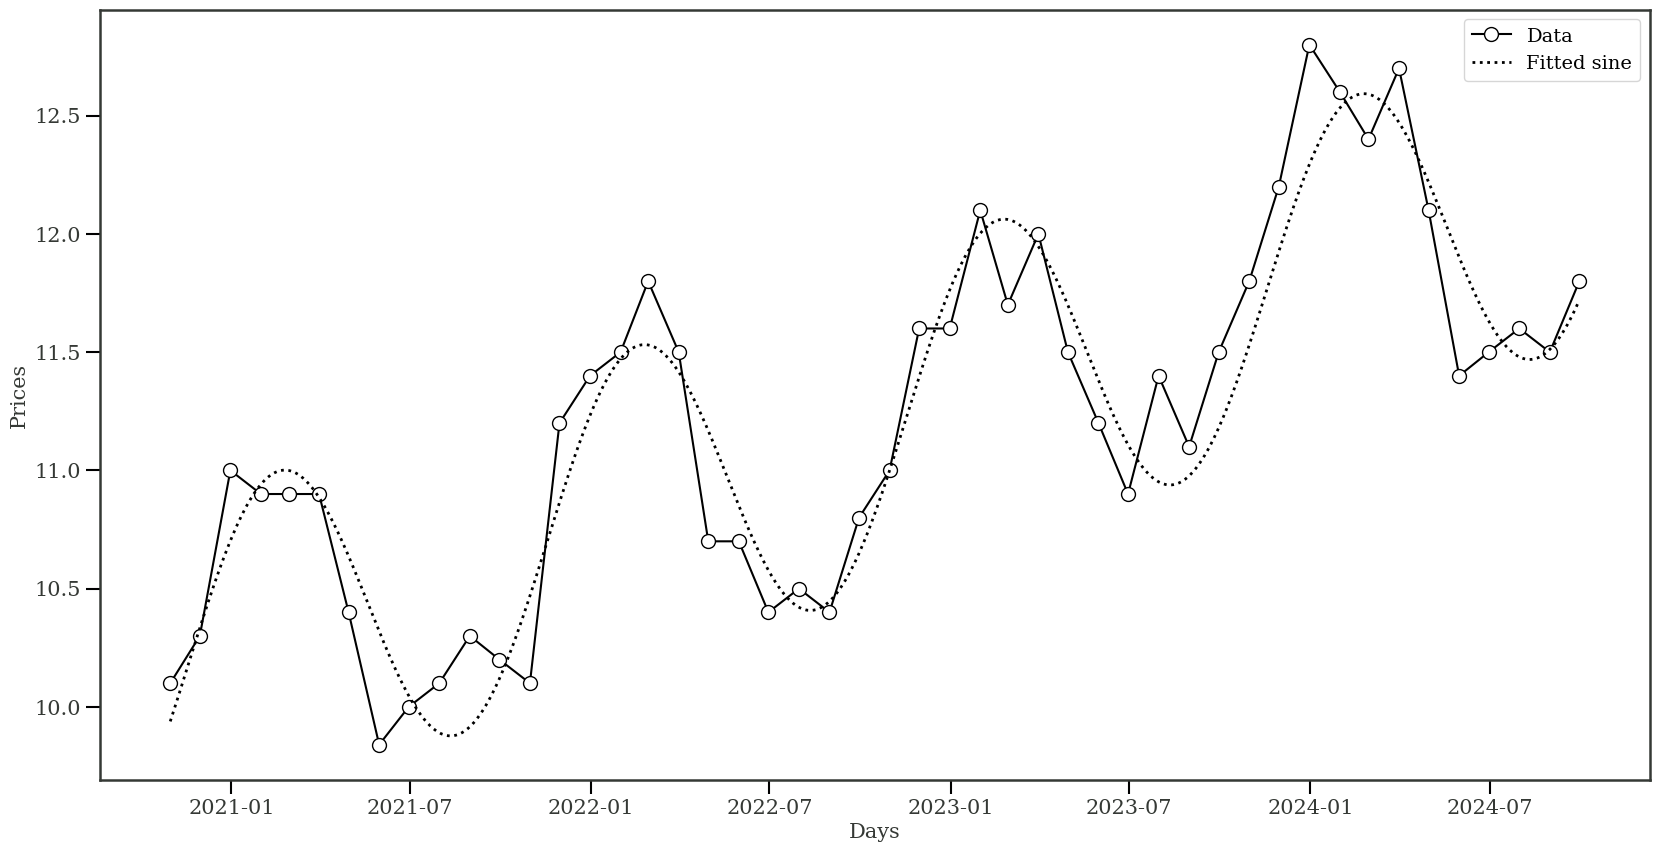

In [70]:
params = {
    'mathtext.rm': 'DejaVu serif',
    'font.family': 'DejaVu serif',
    'font.serif': 'DejaVu serif'
}
matplotlib.rcParams.update(params)

fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot(df['Dates'], df['Prices'], marker='o', markerfacecolor='white',
        markeredgecolor='black', markersize=10, linewidth=1.5, color='black', label='Data')
ax.plot(daily_df.index, daily_df['Smoothed'], linestyle=':', color='#000000', linewidth=2, label='Fitted sine')

ax.set_xlabel('Days', fontweight='normal', fontsize=15, color='#353935')
ax.set_ylabel('Prices', fontweight='normal', fontsize=15, color='#353935')

for spine in ax.spines.values():
    spine.set_linewidth(1.8)
    spine.set_color('#353935')

ax.tick_params(axis='both', which='major', labelsize=15, width=1.5, length=10)
ax.tick_params(axis='both', which='minor', width=1.5, length=3)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

ax.legend(fontsize=14)
plt.show()


In [74]:
daily_df

,Prices,time_in_days,Smoothed
Dates,,,
2020-10-31,10.100000,0.000000,9.938490
2020-11-01,10.106667,1.033333,9.951281
2020-11-02,10.113333,2.066667,9.964130
2020-11-03,10.120000,3.100000,9.977035
2020-11-04,10.126667,4.133333,9.989992
...,...,...,...
2024-09-26,11.760000,1456.000000,11.683261
2024-09-27,11.770000,1457.000000,11.692228
2024-09-28,11.780000,1458.000000,11.701352


In [73]:
def price_contract(in_dates, in_prices, out_dates, out_prices,
                   rate, storage_cost_rate, total_vol, cost_rate):
    volume = 0
    total_buy = 0
    total_sell = 0
    all_dates = sorted(set(in_dates + out_dates))

    for d in all_dates:
        if d in in_dates:
            price = in_prices[in_dates.index(d)]
            if volume + rate <= total_vol:
                volume += rate
                total_buy += rate * (price + cost_rate)
                print(f"Injected on {d} at ${price}")
            else:
                print(f"Cannot inject on {d}: Not enough storage.")
        
        elif d in out_dates:
            price = out_prices[out_dates.index(d)]
            if volume >= rate:
                volume -= rate
                total_sell += rate * (price - cost_rate)
                print(f"Withdrew on {d} at ${price}")
            else:
                print(f"Cannot withdraw on {d}: Not enough gas stored.")
    months = math.ceil((max(out_dates) - min(in_dates)).days / 30)
    storage_cost = months * storage_cost_rate
    
    return total_sell - (total_buy + storage_cost)


In [78]:
in_df = df.iloc[:25] 
out_df = df.iloc[20:]

in_dates = in_df['Dates'].tolist()
in_prices = in_df['Prices'].tolist()

out_dates = out_df['Dates'].tolist()
out_prices = out_df['Prices'].tolist()

rate = 100000
storage_cost_rate = 10000
max_volume = 500000
cost_rate = 0.0005

result = price_contract(in_dates, in_prices, out_dates, out_prices,
                        rate, storage_cost_rate, max_volume, cost_rate)

print(f"\nContract Value: ${result:.2f}")

Injected on 2020-10-31 00:00:00 at $10.1
Injected on 2020-11-30 00:00:00 at $10.3
Injected on 2020-12-31 00:00:00 at $11.0
Injected on 2021-01-31 00:00:00 at $10.9
Injected on 2021-02-28 00:00:00 at $10.9
Cannot inject on 2021-03-31 00:00:00: Not enough storage.
Cannot inject on 2021-04-30 00:00:00: Not enough storage.
Cannot inject on 2021-05-31 00:00:00: Not enough storage.
Cannot inject on 2021-06-30 00:00:00: Not enough storage.
Cannot inject on 2021-07-31 00:00:00: Not enough storage.
Cannot inject on 2021-08-31 00:00:00: Not enough storage.
Cannot inject on 2021-09-30 00:00:00: Not enough storage.
Cannot inject on 2021-10-31 00:00:00: Not enough storage.
Cannot inject on 2021-11-30 00:00:00: Not enough storage.
Cannot inject on 2021-12-31 00:00:00: Not enough storage.
Cannot inject on 2022-01-31 00:00:00: Not enough storage.
Cannot inject on 2022-02-28 00:00:00: Not enough storage.
Cannot inject on 2022-03-31 00:00:00: Not enough storage.
Cannot inject on 2022-04-30 00:00:00: Not